In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

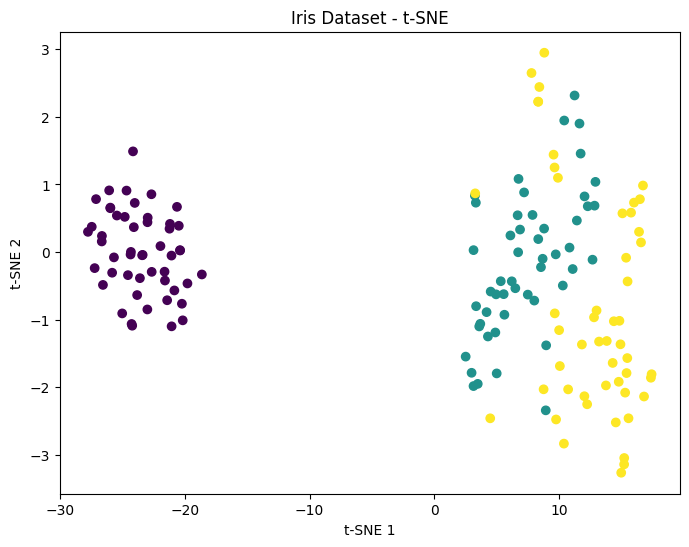

In [2]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Scale
X_scaled = StandardScaler().fit_transform(X)

# PCA preprocessing
X_pca = PCA(n_components=4).fit_transform(X_scaled)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Iris Dataset - t-SNE")
plt.show()

## Diamond dataset

In [3]:
import seaborn as sns

df = sns.load_dataset("diamonds")

print(df.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


## Step 2: Convert Categorical Features

In [4]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in ['cut', 'color', 'clarity']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

## Step 3: Select Features

In [5]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

## Step 4: Standardize Data

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 5: Apply PCA First

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=9)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(53940, 9)


## Step 6: Apply t-SNE

In [9]:
import pandas as pd
from sklearn.manifold import TSNE

sample_idx = df.sample(3000, random_state=42).index

X_sample = X_pca[sample_idx]
y_sample = y.loc[sample_idx]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

## Step 7: Create Price Categories

In [10]:
price_category = pd.qcut(
    y_sample,
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

## Step 8: Visualization

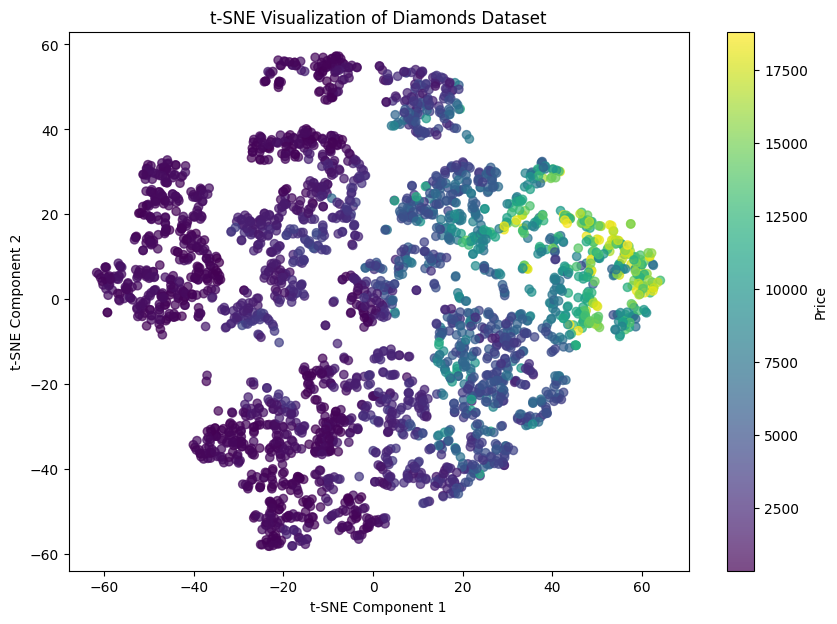

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y_sample,
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(scatter, label='Price')
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Diamonds Dataset")
plt.show()

## Color by Cut

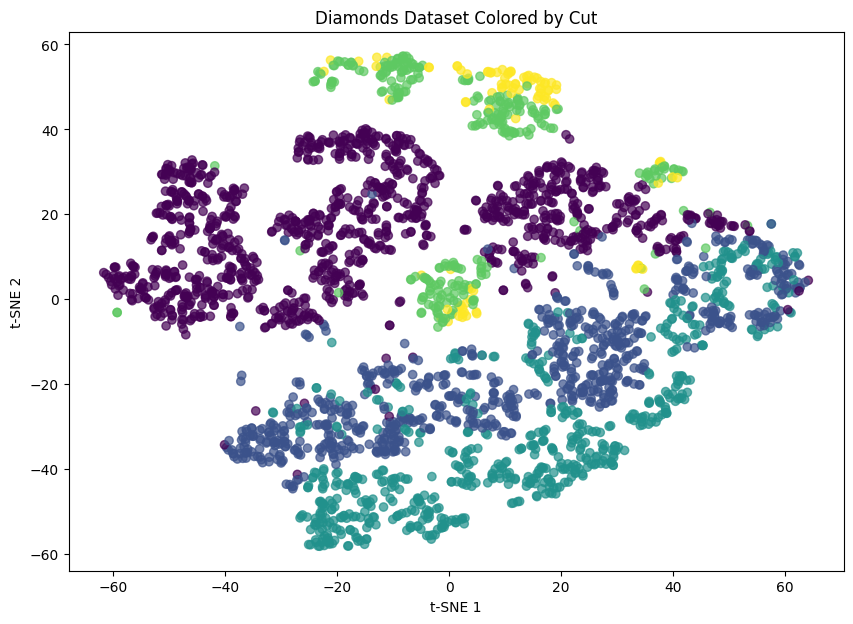

In [12]:
sample_df = df.loc[sample_idx]

cuts = sample_df['cut'].astype('category').cat.codes

plt.figure(figsize=(10,7))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=cuts,
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Diamonds Dataset Colored by Cut")
plt.show()